### Какие товары приносят прибыль, а какие - убытки и что делать с этим (ABC-XYZ анализ)

#### Цель проекта
Определить, какие товары генерируют основную прибыль и где скрыты риски нестабильного спроса. Предложить действия для оптимизации ассортимента с минимальными затратами.

#### Критический инсайт
76.5% маржинальной прибыли генерируется всего тремя товарами. При всем при этом спрос на эти товары нестабилен. Требуется усиленный контроль запасов и диверсификация рисков.

#### Ключевые инсайты

1. **Три товара тянут бизнес, но они ненадежны:** "Беспроводные наушники", "Умная колонка" и "Ортопедическая подушка" генерируют 76.5% прибыли, но при этом продажи скачут - в некоторые недели спрос падает на 11-20%, а в некоторые - растет. Если в пик спроса товар не окажется на складе, бизнес потеряет львиную долю прибыли.
2. **Один стабильный товар для масштабирования:** позиция "Джинсы классические" - единственный товар с предсказуемым спросом из ассортимента (отклонение менее 10%). Является идеальным кандидатом для масштабирования.
3. **"Футболка оверсайз" и ее "нестабильность":** формально эта позиция показывает хаотичный спрос (61% отклонения), но если мы исключим те 18 дней, когда товар отсутствовал на складе, мы получим реальное отклонение спроса в 9.6%. Несмотря на трехнедельное отсутствие, товар продемонстрировал стабильный спрос за следующие семь недель.
4. **"Платье летнее" - низкомаржинальный товар с сезонным характером:** "Платье летнее" имеет ярко выраженный сезонный спрос. Нет смысла держать товар на складе круглый год, платя за его хранение.

#### Рекомендации
1. Прежде чем увеличивать страховые запасы трех наших главных товаров по прибыли, **нужно изучить природу нестабильного спроса**. Необходимо проанализировать причины нестабильности: действия конкурентов, изменения в ранжировании на маркетплейсе, сезонность товара и так далее. Если причина во внешних факторах (акции, сезонность) - увеличенный запас оправдан. Если причина в падении интереса к товару - не увеличивать запас, а работать с карточкой продавца.
2. В случае влияния внешних факторов на стабильность спроса, при следующей закупке **протестировать увеличение размера партии на 20-30% для "Умной колонки"** (спрос на нее самый нестабильный в этой категории - почти 20% отклонения). Проверяем, покрывает ли увеличенный запас пики спроса. Также проверяем, сколько дополнительной прибыли получено за счет того, что товар был в наличии в моменты скачков спроса, достаточно ли у нас оставалось запасов, а также сколько денег "заморозилось" в лишнем товаре. На основе этого принимаем решение о необходимости или отсутствии необходимости увеличить запасы товара на складе.
3. **Протестировать гипотезу с расширением ассортимента для позиции "Джинсы классические"** (например, черные джинсы или другие максимально близкие варианты). Закупить минимальную партию, запустить на продажу. Мониторим конверсию и спрос в течение 2-4 недель. Если черные джинсы продаются со скоростью примерно 75-80% относительно классических - масштабируемся, если ниже 50% - выводим из продажи и больше не закупаем, минимальные потери.
4. Несмотря на фактически высокий спрос позиции "Футболка оверсайз" (когда она есть на складе), бизнес-модель товара убыточна. **Необходимо проверить, возможно ли математически сделать товар прибыльным:** повысить цену на 15-20% на 1-2 дня, чтобы проверить спрос или попробовать сбить себестоимость на 10-15%. Если математика не сходится, распродаем товар по себестоимости и выводим из ассортимента. Если математика сходится, делаем только один минимальный заказ. Если метрики не улучшаются, распродаем по себестоимости и выводим из ассортимента.
5. Поднять маржинальность товаров "Худи базовое" и "Органайзер для белья". **Протестировать поэтапное повышение цены на 1-2% для одной из позиций** с мониторингом общей прибыли и количества заказов в течение 3-4 дней. Повторяем до достижения маржинальности 15-20% для товара. Если происходит снижение общих заказов на 30-40%, откатываем на последний успешный шаг. **Альтернатива - протестировать бандлы:** продавать товар в связке с более маржинальными товарами. Если после 2-3 итераций тестов не удается поднять маржинальность на 15-20% без критического падения спроса (более 30%), то рассматриваем вывод этих позиций из ассортимента и замену на аналоги с лучшей юнит-экономикой.
6. Товар "Платье летнее" имеет ярко выраженный и предсказуемый сезонный спрос. **Необходимо распродать и вывести товар из ассортимента вне сезона, но в дальнейшем закупить товар небольшой партией перед началом сезона (апрель-май) для проверки спроса и маржинальности.** Если в сезон маржинальность не будет достигать хотя бы 15-20%, то исключаем товар окончательно.

In [23]:
import pandas as pd
import numpy as np
from IPython.display import Markdown, display

# Берем данные за 12 недель

data = {
    'sku': ['EL-001', 'EL-002', 'EL-003', 'HO-001', 'HO-002', 'HO-003', 'CL-001', 'CL-002', 'CL-003', 'CL-004'],
    'product_name': [
        'Беспроводные наушники TWS', 'Умная колонка', 'Портативная зарядка 20000mAh',
        'Ортопедическая подушка', 'Набор кухонных ножей', 'Органайзер для белья',
        'Футболка оверсайз (XL)', 'Джинсы классические', 'Худи базовое', 'Платье летнее'
    ],
    'category': ['Электроника'] * 3 + ['Товары для дома'] * 3 + ['Одежда'] * 4,
    'revenue': [450000, 380000, 120000, 210000, 150000, 95000, 180000, 250000, 190000, 140000],
    'margin': [135000, 114000, 18000, 76000, 22000, 12000, -15000, 25000, 15000, 8000],
    
    'w1':  [120, 45, 30, 50, 40, 25, 40, 60, 45, 20],
    'w2':  [135, 52, 35, 48, 45, 28, 42, 58, 50, 22],
    'w3':  [110, 38, 25, 55, 35, 22, 0, 65, 42, 25],
    'w4':  [165, 68, 48, 62, 58, 38, 0, 72, 58, 35],
    'w5':  [95, 35, 22, 45, 32, 20, 0, 55, 48, 30],
    'w6':  [125, 48, 32, 52, 42, 28, 38, 62, 45, 38],
    'w7':  [105, 42, 28, 58, 38, 24, 35, 58, 52, 42],
    'w8':  [155, 62, 45, 65, 55, 35, 48, 75, 62, 48],
    'w9':  [115, 45, 30, 48, 40, 25, 42, 60, 48, 55],
    'w10': [128, 50, 35, 52, 43, 27, 40, 63, 50, 62],
    'w11': [118, 46, 32, 50, 41, 26, 44, 61, 49, 68],
    'w12': [145, 58, 42, 58, 48, 32, 46, 68, 55, 75],
    
    'out_of_stock_days': [0, 0, 0, 0, 0, 0, 18, 0, 0, 0],
    'lead_time_days': [14, 14, 21, 7, 10, 5, 30, 25, 20, 20]
}

df = pd.DataFrame(data)

# Создаем две таблицы для товаров в зависимости от их маржинальности (положительная или отрицательная)
df_abc = df[['sku', 'product_name', 'margin']].copy()
df_profitable = df_abc[df_abc['margin'] > 0].sort_values('margin', ascending=False)
df_unprofitable = df_abc[df_abc['margin'] <= 0]

# Считаем для прибыльных товаров
total_margin = df_profitable['margin'].sum()
df_profitable['cumulative_margin'] = df_profitable['margin'].cumsum()
df_profitable['cumulative_percent'] = (df_profitable['cumulative_margin'] / total_margin) * 100

# Присваиваем категории
bins = [0, 80, 95, 100]
labels = ['A', 'B', 'C']
df_profitable['abc_class'] = pd.cut(df_profitable['cumulative_percent'], 
                                     bins=bins, 
                                     labels=labels, 
                                     include_lowest=True)

# Отделяем убыточные товары, выдавая им отдельную категорию
df_unprofitable['abc_class'] = 'D'
df_unprofitable['cumulative_margin'] = np.nan
df_unprofitable['cumulative_percent'] = np.nan

# Соединяем в одну таблицу
df_abc_final = pd.concat([df_profitable, df_unprofitable])

df_abc_final = df_abc_final.rename(columns={
    'sku': 'Артикул',
    'product_name': 'Название товара',
    'margin': 'Маржинальная прибыль (руб.)',
    'cumulative_margin': 'Накопленная прибыль (руб.)',
    'cumulative_percent': 'Накопленный %',
    'abc_class': 'Класс ABC'
})

df_abc_final = df_abc_final.reset_index(drop=True)

df_abc_final['Маржинальная прибыль (руб.)'] = df_abc_final['Маржинальная прибыль (руб.)'].round(0)
df_abc_final['Накопленная прибыль (руб.)'] = df_abc_final['Накопленная прибыль (руб.)'].round(0)
df_abc_final['Накопленный %'] = df_abc_final['Накопленный %'].round(1)

display(Markdown('### Рейтинг маржинальности (A - лучшее, C - худшее, D - убыточное)'))
display(df_abc_final.style
    .format({
        'Маржинальная прибыль (руб.)': '{:,.0f}',
        'Накопленная прибыль (руб.)': '{:,.0f}',
        'Накопленный %': '{:.1f}'
    })
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}]))

### Рейтинг маржинальности (A - лучшее, C - худшее, D - убыточное)

,Артикул,Название товара,Маржинальная прибыль (руб.),Накопленная прибыль (руб.),Накопленный %,Класс ABC
0,EL-001,Беспроводные наушники TWS,"135,000","135,000",31.8,A
1,EL-002,Умная колонка,"114,000","249,000",58.6,A
2,HO-001,Ортопедическая подушка,"76,000","325,000",76.5,A
3,CL-002,Джинсы классические,"25,000","350,000",82.4,B
4,HO-002,Набор кухонных ножей,"22,000","372,000",87.5,B
5,EL-003,Портативная зарядка 20000mAh,"18,000","390,000",91.8,B
6,CL-003,Худи базовое,"15,000","405,000",95.3,C
7,HO-003,Органайзер для белья,"12,000","417,000",98.1,C
8,CL-004,Платье летнее,"8,000","425,000",100.0,C
9,CL-001,Футболка оверсайз (XL),"-15,000",nan,nan,D


In [24]:
# Создаем таблицу для XYZ-анализа
df_xyz = df.drop(df.columns[[2, 3, 4, 17, 18]], axis=1)
sales_cols = df_xyz.columns[2:]

# Ищем коэффициент вариации
df_xyz['mean_sales'] = df_xyz[sales_cols].mean(axis=1)
df_xyz['std_sales'] = df_xyz[sales_cols].std(axis=1)
df_xyz['CV'] = (df_xyz['std_sales'] / df_xyz['mean_sales']) * 100

# Присваиваем категории
bins = [0, 10, 25, 100]
labels = ['X', 'Y', 'Z']

df_xyz['xyz_class'] =  pd.cut(df_xyz['CV'], 
                                     bins=bins, 
                                     labels=labels, 
                                     include_lowest=True)

df_xyz = df_xyz.sort_values(by='xyz_class', ascending=True)

df_xyz = df_xyz.rename(columns={
    'sku': 'Артикул',
    'product_name': 'Название товара',
    'mean_sales': 'Средние продажи (шт/нед)',
    'std_sales': 'Станд. отклонение',
    'CV': 'Коэф. вариации (CV, %)',
    'xyz_class': 'Класс XYZ'
})

df_xyz = df_xyz.reset_index(drop=True)

# Сбрасываем индекс
df_xyz = df_xyz.reset_index(drop=True)

df_xyz_short = df_xyz[['Артикул', 'Название товара', 'Средние продажи (шт/нед)', 
                        'Станд. отклонение', 'Коэф. вариации (CV, %)', 'Класс XYZ']]

df_xyz_short['Средние продажи (шт/нед)'] = df_xyz_short['Средние продажи (шт/нед)'].round(1)
df_xyz_short['Станд. отклонение'] = df_xyz_short['Станд. отклонение'].round(1)
df_xyz_short['Коэф. вариации (CV, %)'] = df_xyz_short['Коэф. вариации (CV, %)'].round(1)

display(Markdown('### Рейтинг стабильности спроса (X - самое стабильное, Z - самое нестабильное)'))
display(df_xyz_short.style
    .format({
        'Средние продажи (шт/нед)': '{:.1f}',
        'Станд. отклонение': '{:.1f}',
        'Коэф. вариации (CV, %)': '{:.1f}'
    })
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}]))

### Рейтинг стабильности спроса (X - самое стабильное, Z - самое нестабильное)

,Артикул,Название товара,Средние продажи (шт/нед),Станд. отклонение,"Коэф. вариации (CV, %)",Класс XYZ
0,CL-002,Джинсы классические,63.1,6.0,9.4,X
1,EL-001,Беспроводные наушники TWS,126.3,20.6,16.3,Y
2,EL-002,Умная колонка,49.1,9.7,19.7,Y
3,EL-003,Портативная зарядка 20000mAh,33.7,7.9,23.4,Y
4,HO-001,Ортопедическая подушка,53.6,6.1,11.4,Y
5,HO-002,Набор кухонных ножей,43.1,7.6,17.6,Y
6,HO-003,Органайзер для белья,27.5,5.2,19.0,Y
7,CL-003,Худи базовое,50.3,5.7,11.3,Y
8,CL-001,Футболка оверсайз (XL),31.2,19.2,61.3,Z
9,CL-004,Платье летнее,43.3,18.4,42.5,Z


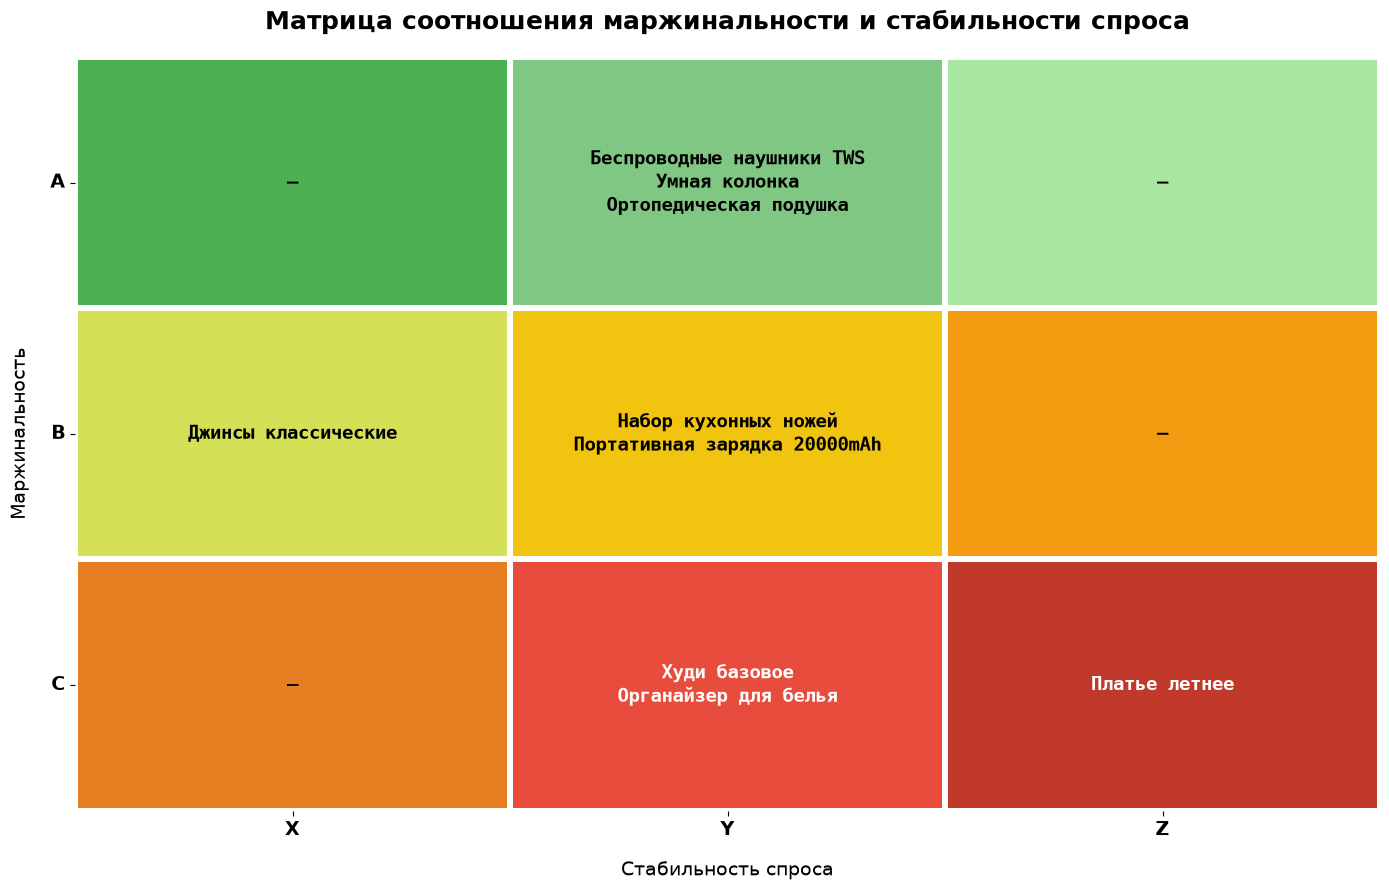

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

df_abc_final = df_abc_final.rename(columns={
    'Артикул': 'sku',
    'Название товара': 'product_name',
    'Маржинальная прибыль (руб.)': 'margin',
    'Накопленная прибыль (руб.)': 'cumulative_margin',
    'Накопленный %': 'cumulative_percent',
    'Класс ABC': 'abc_class'
})

df_xyz = df_xyz.rename(columns={
    'Артикул': 'sku',
    'Название товара': 'product_name',
    'Средние продажи (шт/нед)': 'mean_sales',
    'Станд. отклонение': 'std_sales',
    'Коэф. вариации (CV, %)': 'CV',
    'Класс XYZ': 'xyz_class'
})


# Объединяем таблицы ABC и XYZ и создаем комбинированную категорию
df_final = df_abc_final.merge(df_xyz[['sku', 'CV', 'xyz_class']], on='sku', how='left')
df_final['abc_xyz'] = df_final['abc_class'].astype(str) + df_final['xyz_class'].astype(str)
df_final = df_final.sort_values(by=['abc_class', 'xyz_class'])


# Создадим матрицу с тепловой картой
custom_colors = [
    '#c0392b',
    '#e74c3c',
    '#e67e22',
    '#f39c12',
    '#f1c40f',
    '#d4e157',
    '#a8e6a1',
    '#81c784',
    '#4caf50'
]

custom_cmap = ListedColormap(custom_colors)

quality_matrix = pd.DataFrame(
    [[9, 8, 7],
     [6, 5, 4],
     [3, 2, 1]],
    index=['A', 'B', 'C'],
    columns=['X', 'Y', 'Z']
)

sku_matrix = df_final.groupby(['abc_class', 'xyz_class'])['product_name'].apply(
    lambda x: '\n'.join(x) if len(x) > 0 else '—'
).unstack(fill_value='—')
sku_matrix = sku_matrix.loc[['A', 'B', 'C'], ['X', 'Y', 'Z']]

fig, ax = plt.subplots(figsize=(14, 9))

sns.heatmap(
    quality_matrix, 
    annot=sku_matrix,
    fmt='',
    cmap=custom_cmap,
    linewidths=3,
    linecolor='white',
    cbar=False,
    annot_kws={'size': 14, 'weight': 'bold', 'family': 'monospace'},
    vmin=1, vmax=9
)

for i, text in enumerate(ax.texts):
    if i in [7, 8]:
        text.set_color('white')
    else:
        text.set_color('black')

plt.title('Матрица соотношения маржинальности и стабильности спроса', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Стабильность спроса', fontsize=14, labelpad=15)
plt.ylabel('Маржинальность', fontsize=14, labelpad=15)

plt.xticks(rotation=0, fontsize=14, fontweight='bold')
plt.yticks(rotation=0, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()